# SpreadVsPrecision

Проверяем, что важнее для success/drop: насколько патч расползся по feature map (`spread_*`) или попала ли дельта в важные по SegmentIG нейроны (`precision_*`).

Новая метрика: `spread_object_bbox_delta_*` — сырая энергия `Δ` внутри bbox объекта до атаки. Она считается из уже сохранённых `delta_chw` и `clean_detection.bbox_xyxy_orig`, без нового прохода модели, и кэшируется в отдельном derived cache.

## Setup и общий cache

In [1]:
from pathlib import Path
import os
import sys
import tempfile

_plot_cache = Path(tempfile.gettempdir()) / "patch_success_plot_cache"
_mpl_cache = _plot_cache / "matplotlib"
_xdg_cache = _plot_cache / "xdg"
_mpl_cache.mkdir(parents=True, exist_ok=True)
_xdg_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_mpl_cache))
os.environ.setdefault("XDG_CACHE_HOME", str(_xdg_cache))

_nb_cwd = Path.cwd()
if (_nb_cwd / "new_experiments" / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd / "new_experiments"))
elif (_nb_cwd / "patch_success_analysis").exists():
    sys.path.insert(0, str(_nb_cwd))
else:
    raise RuntimeError(f"Unexpected cwd={_nb_cwd}; run from repo root or new_experiments")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from patch_success_analysis.notebook_setup import ensure_new_experiments_cwd, make_coco_people_patch_success_experiment
from patch_success_analysis import spread_precision

cwd = ensure_new_experiments_cwd()
layer_name = "model.22"
attack_config, config, exp = make_coco_people_patch_success_experiment(target_layer=layer_name)
cache = exp.build_or_load_cache(force=False)
print(f"cwd={cwd}")
print(f"target_layer={config.target_layer}, target_mode={config.target_mode}")
print(f"attack cache key={attack_config.cache_key()}")
print(f"attack cache path={attack_config.cache_path}")
print(cache.to_summary())

Matplotlib is building the font cache; this may take a moment.


cwd=/Users/ashentide/PycharmProjects/PatchSuccessResearch/new_experiments
target_layer=model.22, target_mode=class_only
attack cache key=e91cdfc4a2c4e20d
attack cache path=new_experiments/outputs/patch_success_analysis/cache/attack_pool_e91cdfc4a2c4e20d.pkl
{'cache_key': 'e91cdfc4a2c4e20d', 'config': {'dataset_path': ['../datasets/COCO_people'], 'patch_path': '../data/patch.png', 'model_path': 'yolo11s.pt', 'output_dir': 'new_experiments/outputs/patch_success_analysis', 'imgsz': 640, 'device': 'mps', 'target_class_name': 'person', 'conf': 0.01, 'success_thresh': 0.3, 'seed': 17, 'pool_size': 7200, 'n_success': 3000, 'n_fail': 3000, 'apply_patch_after_letterbox': True, 'patch_xy': (0, 0)}, 'balanced_total': 5650, 'balanced_success': 3000, 'balanced_fail': 2650, 'pool_total': 7200, 'pool_success': 4550, 'pool_fail': 2650, 'pool_failed_images': 0, 'failed_paths': []}


## Расчёт / загрузка spread-vs-precision cache

In [2]:
force_spread_vs_precision_recompute = False
max_examples = None
top_percent = 5.0

svp = spread_precision.compute_or_load_spread_vs_precision(
    exp,
    layer_name=layer_name,
    max_examples=max_examples,
    top_percent=top_percent,
    force=force_spread_vs_precision_recompute,
)
rows_df = pd.DataFrame(svp["rows"])
quality_df = svp["quality"]
regression_df = svp["regression"]

print(f"spread-vs-precision cache: {svp['cache_path']}")
print(f"loaded_from_cache={svp['loaded_from_cache']}")
print(f"rows={len(rows_df)}, skipped={len(svp.get('skipped', []))}")
print(f"spread metrics={len(svp['spread_cols'])}, precision metrics={len(svp['precision_cols'])}")
if svp.get("skipped"):
    display(pd.DataFrame(svp["skipped"]).head(20))
display(rows_df.head())

spread-vs-precision cache: new_experiments/outputs/patch_success_analysis/cache/spread_vs_precision_aa9d7c3ac090030f.pkl
loaded_from_cache=True
rows=5646, skipped=4
spread metrics=16, precision metrics=48


,path,success,drop,reason
0,../datasets/COCO_people/03520_train2017_image1...,False,-0.147283,missing layer_maps cache
1,../datasets/COCO_people/03370_train2017_image5...,False,-0.751137,missing layer_maps cache
2,../datasets/COCO_people/01029_train2017_image3...,False,-0.195723,missing layer_maps cache
3,../datasets/COCO_people/04404_train2017_image7...,False,0.000000,missing layer_maps cache


,path,success,drop,conf_clean,conf_patch,layer_maps_cache_path,layer_maps_loaded_from_cache,spread_delta_l2_rms,spread_delta_abs_mean,spread_delta_max,...,precision_delta_importance_product_top10_raw,precision_delta_importance_product_top10_logbase_1p5,precision_delta_importance_product_top10_logbase_2,precision_delta_importance_product_top10_logbase_e,precision_delta_importance_product_top10_logbase_10,precision_delta_importance_product_top10_power_0p25,precision_delta_importance_product_top10_power_0p5,precision_delta_importance_product_top10_power_0p75,precision_delta_importance_product_top10_trim_q99,precision_delta_importance_product_top10_trim_q99p5
0,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,0.933572,0.531450,new_experiments/outputs/patch_success_analysis...,True,0.418452,0.379149,1.536216,...,0.001292,0.001540,0.001749,0.002010,0.003661,0.018522,0.006512,0.002701,0.000809,0.000945
1,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,0.876672,0.240576,new_experiments/outputs/patch_success_analysis...,True,0.424965,0.401782,1.476797,...,0.000173,0.000208,0.000239,0.000280,0.000580,0.011682,0.002293,0.000563,0.000083,0.000107
2,../datasets/COCO_people/01552_train2017_image1...,True,0.876263,0.876263,0.000000,new_experiments/outputs/patch_success_analysis...,True,0.553894,0.521083,1.423172,...,0.000437,0.000533,0.000616,0.000724,0.001478,0.015081,0.003964,0.001226,0.000324,0.000364
3,../datasets/COCO_people/02665_train2017_image8...,True,0.369444,0.926853,0.557409,new_experiments/outputs/patch_success_analysis...,True,0.417321,0.378867,1.523832,...,0.000656,0.000798,0.000921,0.001079,0.002170,0.019195,0.005296,0.001736,0.000415,0.000486
4,../datasets/COCO_people/04480_train2017_image1...,False,0.004722,0.900169,0.895448,new_experiments/outputs/patch_success_analysis...,True,0.331352,0.293996,1.403473,...,0.000547,0.000661,0.000759,0.000883,0.001707,0.012105,0.003649,0.001312,0.000364,0.000419


## Raw delta spread metrics vs precision ratios

In [3]:
spread_cols = svp["spread_cols"]
precision_cols = svp["precision_cols"]

main_spread_cols = [
    "spread_delta_l2_rms",
    "spread_delta_abs_mean",
    "spread_delta_max",
    "spread_delta_gini",
    "spread_roi_energy_frac",
    "spread_object_bbox_delta_frac",
    "spread_object_bbox_delta_mean",
    "spread_delta_total_abs",
]
main_precision_cols = [
    "precision_align_cosine",
    "precision_align_top_jaccard",
    "precision_importance_energy_in_delta_top",
    "precision_delta_energy_in_importance_top",
    "precision_delta_importance_product_unsigned",
    "precision_delta_importance_product_signed",
    "precision_delta_energy_importance_bins_top10_reciprocal",
]
main_spread_cols = [col for col in main_spread_cols if col in rows_df.columns]
main_precision_cols = [col for col in main_precision_cols if col in rows_df.columns]

side_by_side_df = rows_df[["path", "success", "drop", *main_spread_cols, *main_precision_cols]]
display(side_by_side_df)

display(
    rows_df.groupby("success")[main_spread_cols + main_precision_cols]
    .agg(["mean", "std", "median"])
    .rename(index={False: "fail", True: "success"})
)

,path,success,drop,spread_delta_l2_rms,spread_delta_abs_mean,spread_delta_max,spread_delta_gini,spread_roi_energy_frac,spread_object_bbox_delta_frac,spread_object_bbox_delta_mean,spread_delta_total_abs,precision_align_cosine,precision_align_top_jaccard,precision_importance_energy_in_delta_top,precision_delta_energy_in_importance_top,precision_delta_importance_product_unsigned,precision_delta_importance_product_signed,precision_delta_energy_importance_bins_top10_reciprocal
0,../datasets/COCO_people/06356_train2017_image4...,True,0.402123,0.418452,0.379149,1.536216,0.201839,0.111960,0.497160,0.396838,45906.464844,0.078658,0.038961,0.122424,0.054436,0.001292,0.000309,0.033012
1,../datasets/COCO_people/00972_train2017_image3...,True,0.636096,0.424965,0.401782,1.476797,0.172663,0.110345,0.396879,0.419628,50516.167969,0.040359,0.051821,0.270216,0.065115,0.000173,0.000047,0.040127
2,../datasets/COCO_people/01552_train2017_image1...,True,0.876263,0.553894,0.521083,1.423172,0.193773,0.094664,0.451735,0.581214,60677.851562,0.051325,0.036700,0.092023,0.058711,0.000437,0.000064,0.034946
3,../datasets/COCO_people/02665_train2017_image8...,True,0.369444,0.417321,0.378867,1.523832,0.240077,0.114041,0.489808,0.412382,46602.941406,0.073985,0.056760,0.158848,0.071889,0.000656,0.000076,0.042376
4,../datasets/COCO_people/04480_train2017_image1...,False,0.004722,0.331352,0.293996,1.403473,0.250255,0.148572,0.415319,0.257057,36516.753906,0.039021,0.023335,0.056204,0.040829,0.000547,0.000105,0.024754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5641,../datasets/COCO_people/04280_train2017_image4...,True,0.751893,0.421004,0.380509,1.471777,0.235174,0.113524,0.458725,0.430985,46534.921875,0.020029,0.049718,0.159676,0.064581,0.000190,0.000050,0.038855
5642,../datasets/COCO_people/00033_image353051_ann2...,False,0.000000,0.517320,0.488026,1.541583,0.181761,0.086146,0.000000,0.000000,59415.082031,0.032921,0.050095,0.125881,0.066642,0.000311,0.000035,0.039686
5643,../datasets/COCO_people/03593_train2017_image1...,True,0.770700,0.464764,0.435843,1.462660,0.177672,0.090088,0.280703,0.453121,53839.625000,0.050961,0.033404,0.081599,0.049251,0.000766,0.000180,0.029368
5644,../datasets/COCO_people/00840_train2017_image3...,True,0.726216,0.459620,0.434227,1.501225,0.160769,0.099348,0.675300,0.440953,52402.664062,0.042642,0.047463,0.140955,0.066271,0.000232,-0.000004,0.041590


spread_delta_l2_rms                     spread_delta_abs_mean  \
                       mean       std    median                  mean   
success                                                                 
fail               0.463925  0.068272  0.456470              0.428941   
success            0.482975  0.059064  0.480303              0.449412   

                            spread_delta_max                      \
              std    median             mean       std    median   
success                                                            
fail     0.071246  0.420268         1.513117  0.074589  1.512250   
success  0.061747  0.447451         1.516242  0.074545  1.514087   

        spread_delta_gini  ... precision_delta_energy_in_importance_top  \
                     mean  ...                                   median   
success                    ...                                            
fail             0.212336  ...                                 0.056018   
success          0.204420  ...                                 0.062444   

        precision_delta_importance_product_unsigned                      \
                                               mean       std    median   
success                                                                   
fail                                       0.000739  0.000490  0.000682   
success                                    0.000856  0.000531  0.000803   

        precision_delta_importance_product_signed                      \
                                             mean       std    median   
success                                                                 
fail                                     0.000051  0.000090  0.000032   
success                                  0.000075  0.000105  0.000055   

        precision_delta_energy_importance_bins_top10_reciprocal            \
                                                           mean       std   
success                                                                     
fail                                              0.034008       0.006334   
success                                           0.037434       0.005478   

                   
           median  
success            
fail     0.033923  
success  0.037560  

[2 rows x 45 columns]

## Classification: что лучше делит success/fail

,metric,roc_auc,best_accuracy,best_threshold,best_direction,family
0,precision_delta_energy_in_importance_top,0.667132,0.639568,0.056406,1,precision
1,spread_object_bbox_delta_mean,0.652607,0.639036,0.410522,1,spread
2,precision_align_top_jaccard,0.667112,0.637797,0.039356,1,precision
3,precision_delta_energy_importance_bins_top10_l...,0.666285,0.637088,0.058602,1,precision
4,precision_delta_energy_importance_bins_top10_exp,0.664821,0.635671,0.038404,1,precision
...,...,...,...,...,...,...
59,spread_object_bbox_delta_signed_sum,0.523729,0.538080,-6.465367,1,spread
60,spread_delta_max,0.509062,0.534183,1.366175,1,spread
61,spread_object_bbox_delta_signed_mean,0.521214,0.533121,0.050625,-1,spread
62,spread_delta_nonzero_frac,0.497976,0.532412,0.999988,1,spread


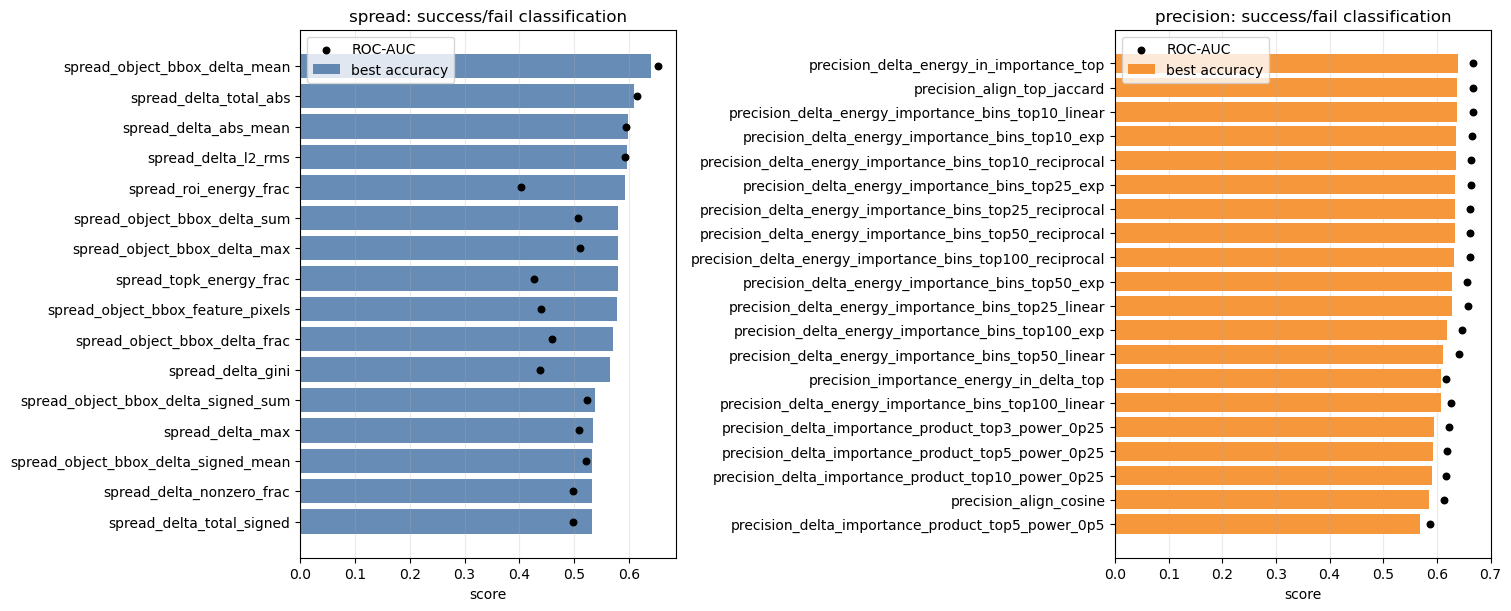

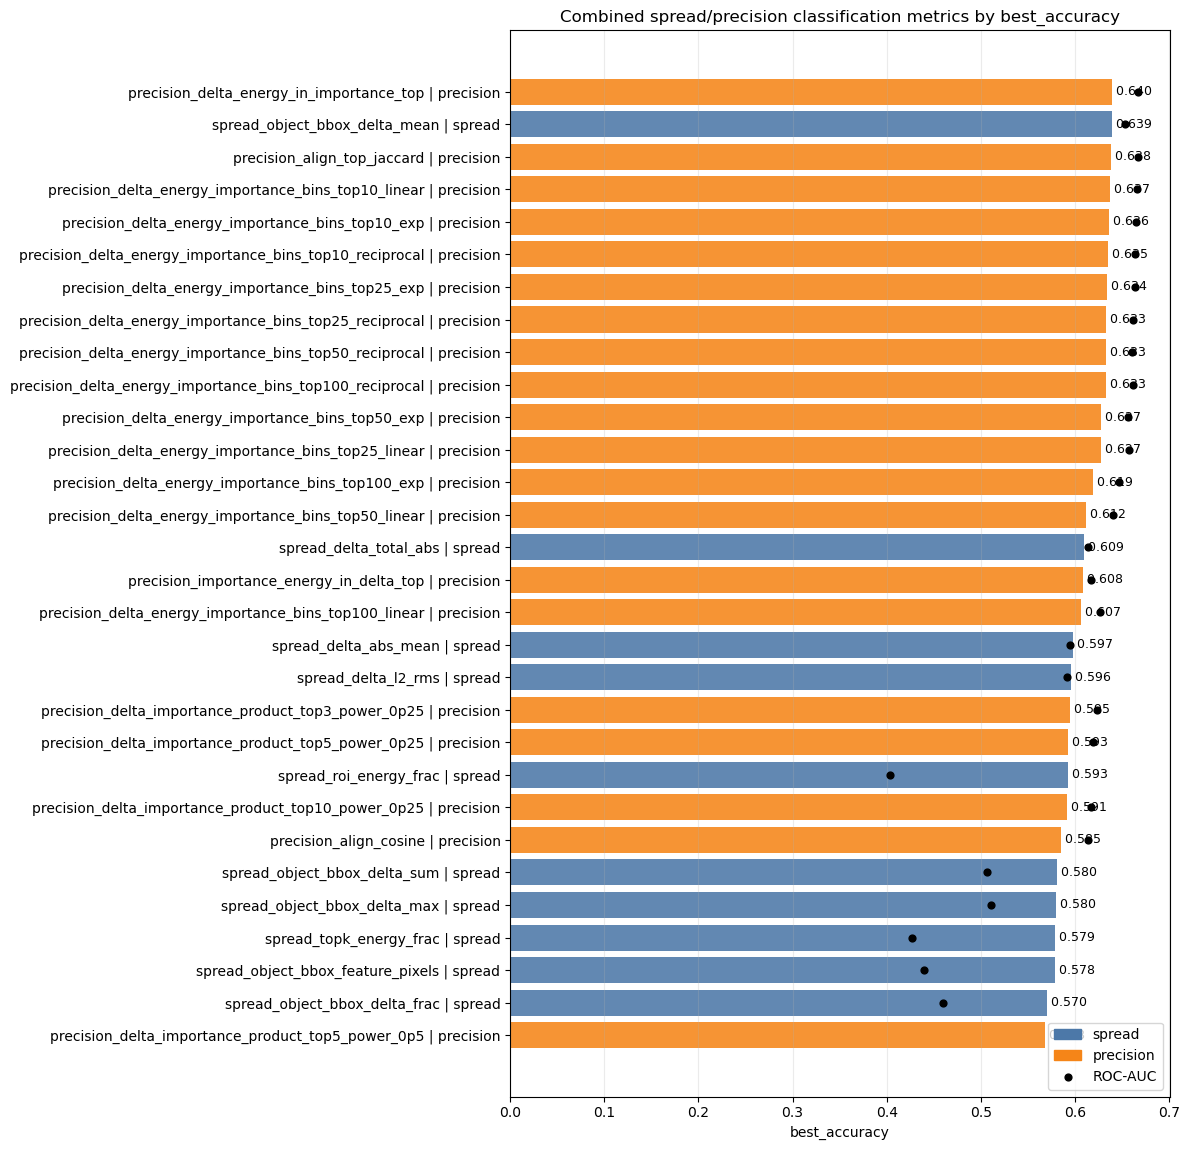

,metric,roc_auc,best_accuracy,best_threshold,best_direction,family
0,precision_delta_energy_in_importance_top,0.667132,0.639568,0.056406,1,precision
2,precision_align_top_jaccard,0.667112,0.637797,0.039356,1,precision
3,precision_delta_energy_importance_bins_top10_l...,0.666285,0.637088,0.058602,1,precision
4,precision_delta_energy_importance_bins_top10_exp,0.664821,0.635671,0.038404,1,precision
5,precision_delta_energy_importance_bins_top10_r...,0.663346,0.635494,0.034357,1,precision
6,precision_delta_energy_importance_bins_top25_exp,0.663349,0.633900,0.077086,1,precision
7,precision_delta_energy_importance_bins_top25_r...,0.661776,0.633369,0.042506,1,precision
8,precision_delta_energy_importance_bins_top50_r...,0.660977,0.633369,0.049811,1,precision
9,precision_delta_energy_importance_bins_top100_...,0.661344,0.632660,0.056564,1,precision
10,precision_delta_energy_importance_bins_top50_exp,0.656164,0.627347,0.146872,1,precision


In [4]:
display(quality_df)

fig = spread_precision.plot_family_quality_side_by_side(quality_df, top_n=20)
plt.show()

fig = spread_precision.plot_family_quality_combined_bar(quality_df, top_n=30, score_col="best_accuracy")
plt.show()

best_by_family = (
    quality_df.sort_values(["family", "best_accuracy", "roc_auc"], ascending=[True, False, False])
    .groupby("family")
    .head(10)
)
display(best_by_family)

## Regression: что лучше похоже на drop

,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score,family
0,spread_object_bbox_delta_mean,5646,1.0,0.286882,0.240876,0.168182,0.286882,0.240876,0.168182,0.211479,...,0.875353,0.035869,0.082301,0.284240,0.324953,0.957966,1.000000,0.510734,0.363407,spread
1,precision_delta_energy_importance_bins_top10_exp,5646,1.0,0.261860,0.267941,0.187063,0.261860,0.267941,0.187063,0.129784,...,12.447714,-0.069903,0.068570,0.285943,0.327375,0.965106,0.613696,0.508878,0.307260,precision
2,precision_delta_energy_importance_bins_top25_exp,5646,1.0,0.257021,0.264682,0.184237,0.257021,0.264682,0.184237,0.120720,...,9.747040,-0.347488,0.066060,0.286386,0.327816,0.966406,0.570837,0.508542,0.299226,precision
3,precision_delta_energy_importance_bins_top10_l...,5646,1.0,0.261631,0.268203,0.187147,0.261631,0.268203,0.187147,0.116277,...,9.346709,-0.138714,0.068451,0.285642,0.327396,0.965168,0.549828,0.508862,0.298641,precision
4,precision_delta_energy_in_importance_top,5646,1.0,0.263398,0.269800,0.187943,0.263398,0.269800,0.187943,0.110920,...,8.503631,-0.072635,0.069379,0.285466,0.327233,0.964687,0.524495,0.508987,0.296217,precision
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,precision_delta_importance_product_top5_raw,5646,1.0,0.105775,0.111684,0.075000,0.105775,0.111684,0.075000,0.012646,...,69.760085,0.376919,0.011188,0.303160,0.337308,0.994390,0.059800,0.501406,0.140977,precision
60,precision_delta_importance_product_top3_raw,5646,1.0,0.106680,0.112584,0.075605,0.106680,0.112584,0.075605,0.007173,...,72.363694,0.376310,0.011381,0.303115,0.337276,0.994293,0.033919,0.501431,0.137763,precision
61,spread_delta_max,5646,1.0,0.025371,0.023829,0.015943,0.025371,0.023829,0.015943,0.009447,...,0.115411,0.257906,0.000644,0.305544,0.339102,0.999678,0.044670,0.500080,0.093353,spread
62,spread_delta_nonzero_frac,5646,1.0,-0.007003,-0.010750,-0.008580,0.007003,0.010750,0.008580,0.012989,...,-879.660663,880.092045,0.000049,0.305746,0.339203,0.999975,0.061420,0.500006,0.089128,spread


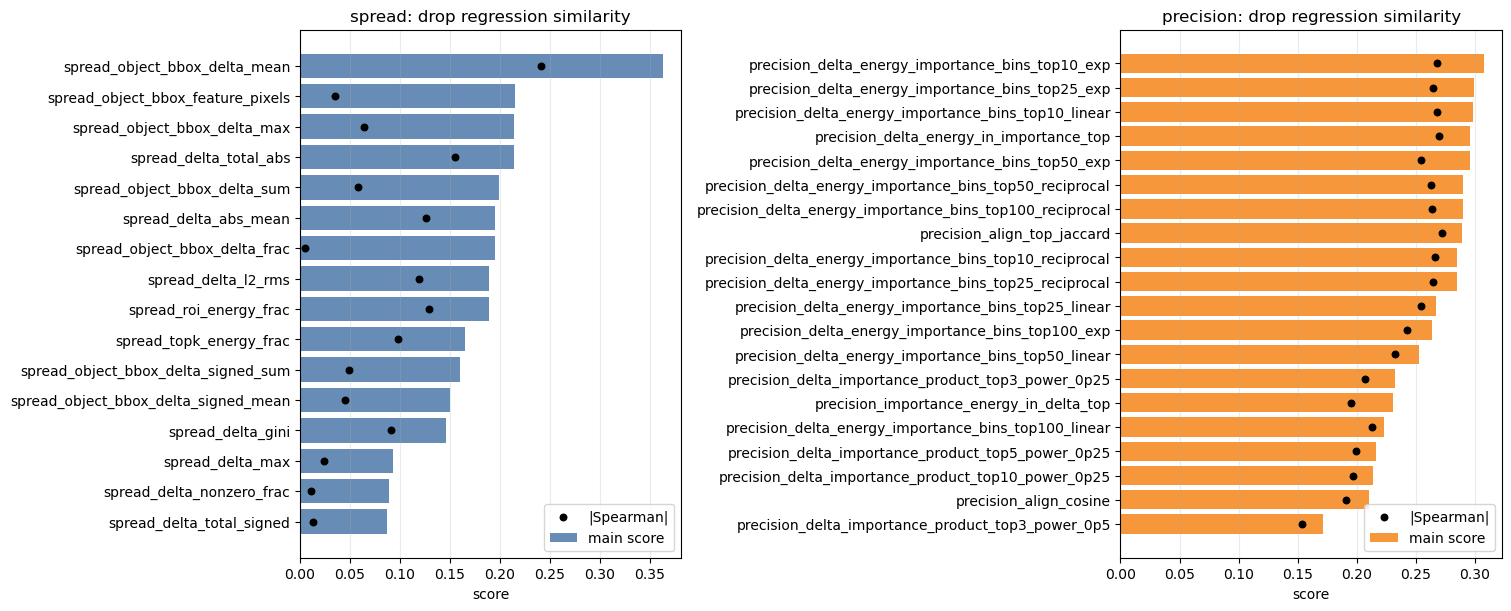

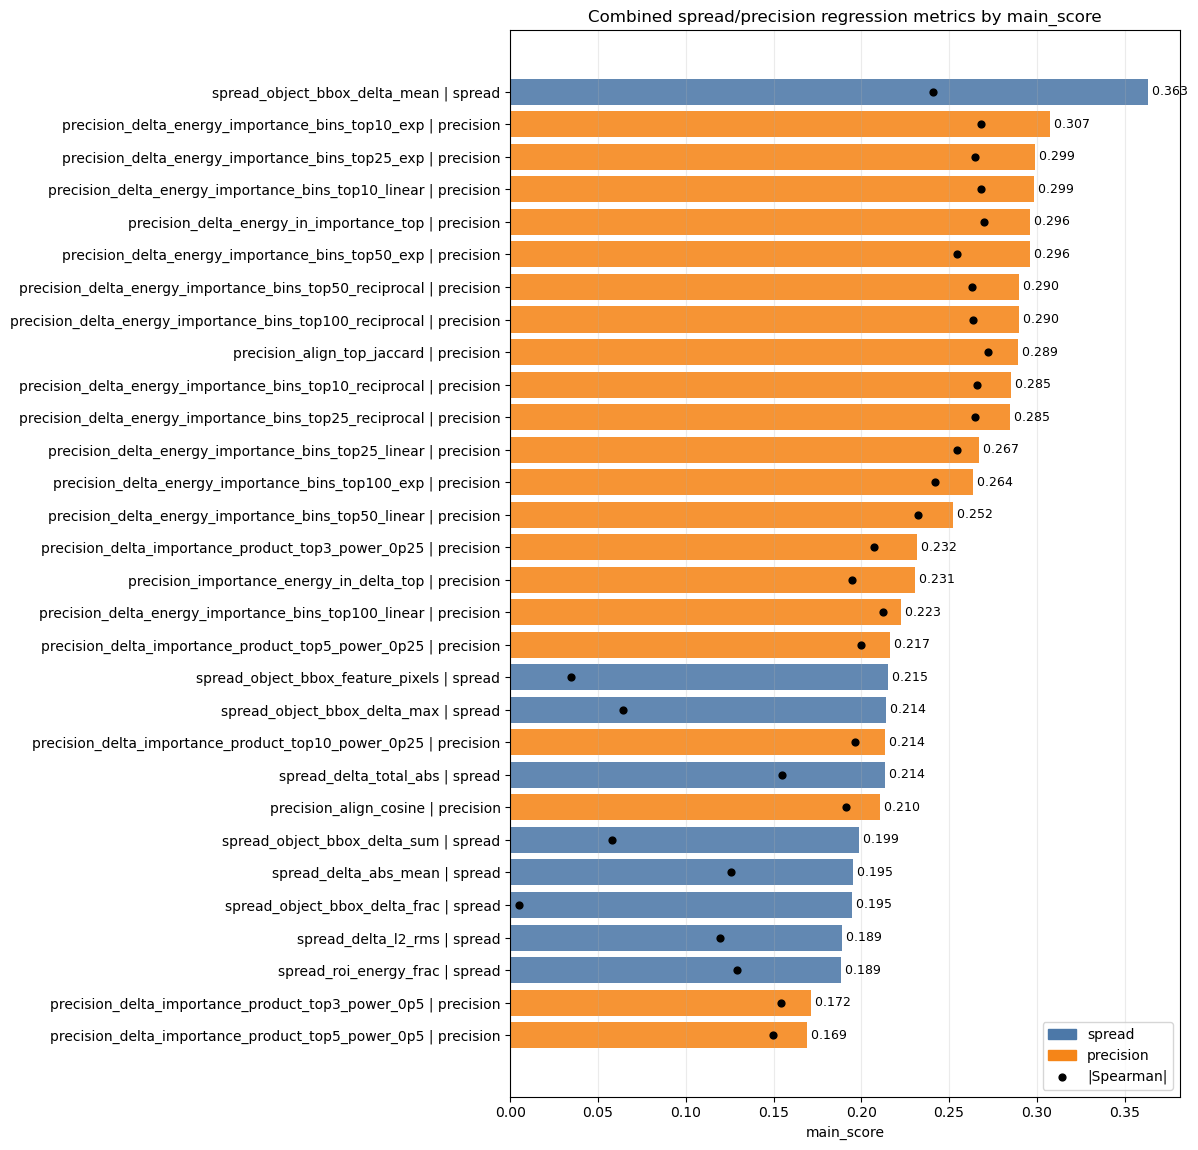

,metric,n,coverage,pearson,spearman,kendall,abs_pearson,abs_spearman,abs_kendall,mutual_info,...,linear_slope,linear_intercept,linear_r2,calibrated_mae,calibrated_rmse,calibrated_nrmse,mutual_info_norm,calibrated_error_score,main_score,family
1,precision_delta_energy_importance_bins_top10_exp,5646,1.0,0.261860,0.267941,0.187063,0.261860,0.267941,0.187063,0.129784,...,12.447714,-0.069903,0.068570,0.285943,0.327375,0.965106,0.613696,0.508878,0.307260,precision
2,precision_delta_energy_importance_bins_top25_exp,5646,1.0,0.257021,0.264682,0.184237,0.257021,0.264682,0.184237,0.120720,...,9.747040,-0.347488,0.066060,0.286386,0.327816,0.966406,0.570837,0.508542,0.299226,precision
3,precision_delta_energy_importance_bins_top10_l...,5646,1.0,0.261631,0.268203,0.187147,0.261631,0.268203,0.187147,0.116277,...,9.346709,-0.138714,0.068451,0.285642,0.327396,0.965168,0.549828,0.508862,0.298641,precision
4,precision_delta_energy_in_importance_top,5646,1.0,0.263398,0.269800,0.187943,0.263398,0.269800,0.187943,0.110920,...,8.503631,-0.072635,0.069379,0.285466,0.327233,0.964687,0.524495,0.508987,0.296217,precision
5,precision_delta_energy_importance_bins_top50_exp,5646,1.0,0.245350,0.254586,0.176419,0.245350,0.254586,0.176419,0.125578,...,8.927102,-0.899512,0.060197,0.288132,0.328843,0.969434,0.593807,0.507760,0.296056,precision
6,precision_delta_energy_importance_bins_top50_r...,5646,1.0,0.256208,0.263227,0.183533,0.256208,0.263227,0.183533,0.109447,...,14.680910,-0.324001,0.065643,0.286949,0.327889,0.966622,0.517530,0.508486,0.290109,precision
7,precision_delta_energy_importance_bins_top100_...,5646,1.0,0.256830,0.263789,0.183946,0.256830,0.263789,0.183946,0.108833,...,14.936513,-0.437958,0.065962,0.286866,0.327833,0.966457,0.514628,0.508529,0.290049,precision
8,precision_align_top_jaccard,5646,1.0,0.264134,0.272449,0.189907,0.264134,0.272449,0.189907,0.098981,...,7.877234,0.108987,0.069767,0.285697,0.327164,0.964486,0.468041,0.509039,0.289415,precision
9,precision_delta_energy_importance_bins_top10_r...,5646,1.0,0.259769,0.265980,0.185737,0.259769,0.265980,0.185737,0.099176,...,14.358331,-0.081708,0.067480,0.286360,0.327566,0.965671,0.468962,0.508732,0.285097,precision
10,precision_delta_energy_importance_bins_top25_r...,5646,1.0,0.257500,0.264726,0.184550,0.257500,0.264726,0.184550,0.100127,...,14.560471,-0.215820,0.066306,0.286755,0.327773,0.966278,0.473462,0.508575,0.284733,precision


In [5]:
display(regression_df)

fig = spread_precision.plot_family_regression_side_by_side(regression_df, top_n=20)
plt.show()

fig = spread_precision.plot_family_regression_combined_bar(regression_df, top_n=30, score_col="main_score")
plt.show()

best_reg_by_family = (
    regression_df.sort_values(["family", "main_score", "abs_spearman"], ascending=[True, False, False])
    .groupby("family")
    .head(10)
)
display(best_reg_by_family)

## Overall: Spearman и Pearson вместо main score


,family,best_abs_spearman,best_abs_pearson,mean_top10_abs_spearman,mean_top10_abs_pearson
0,precision,0.272449,0.264134,0.265556,0.258451
1,spread,0.240876,0.286882,0.112969,0.125166


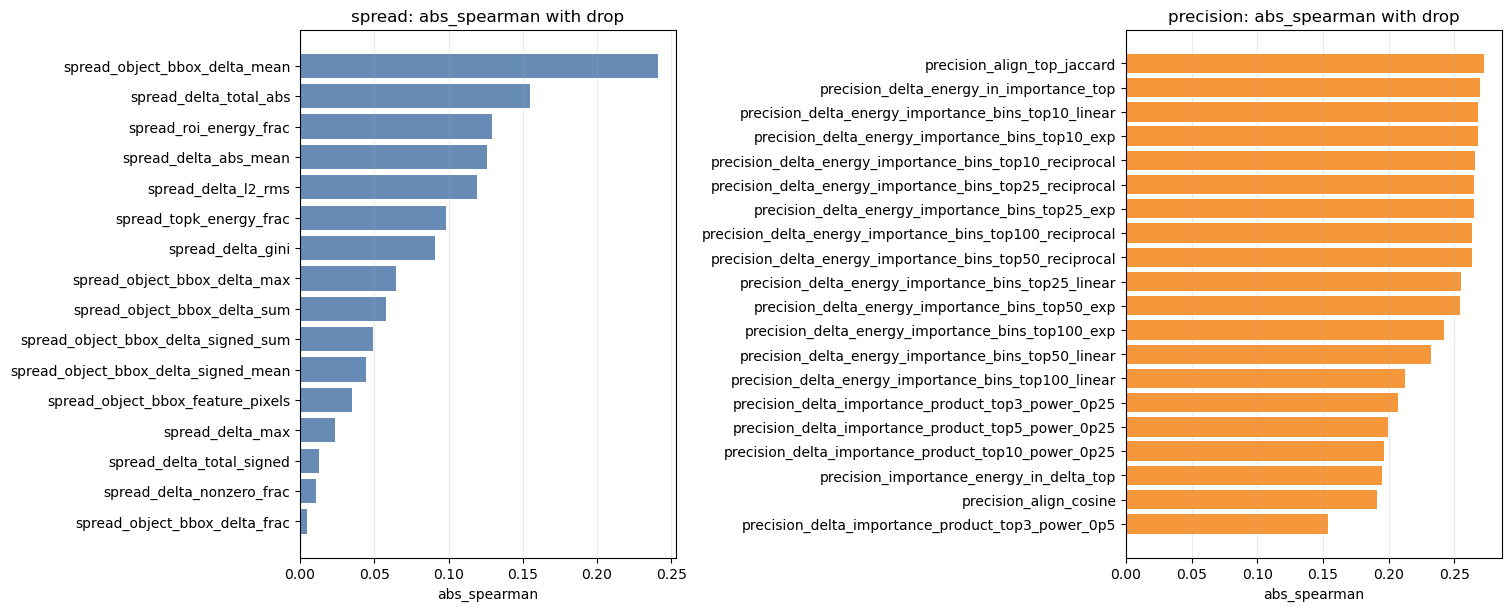

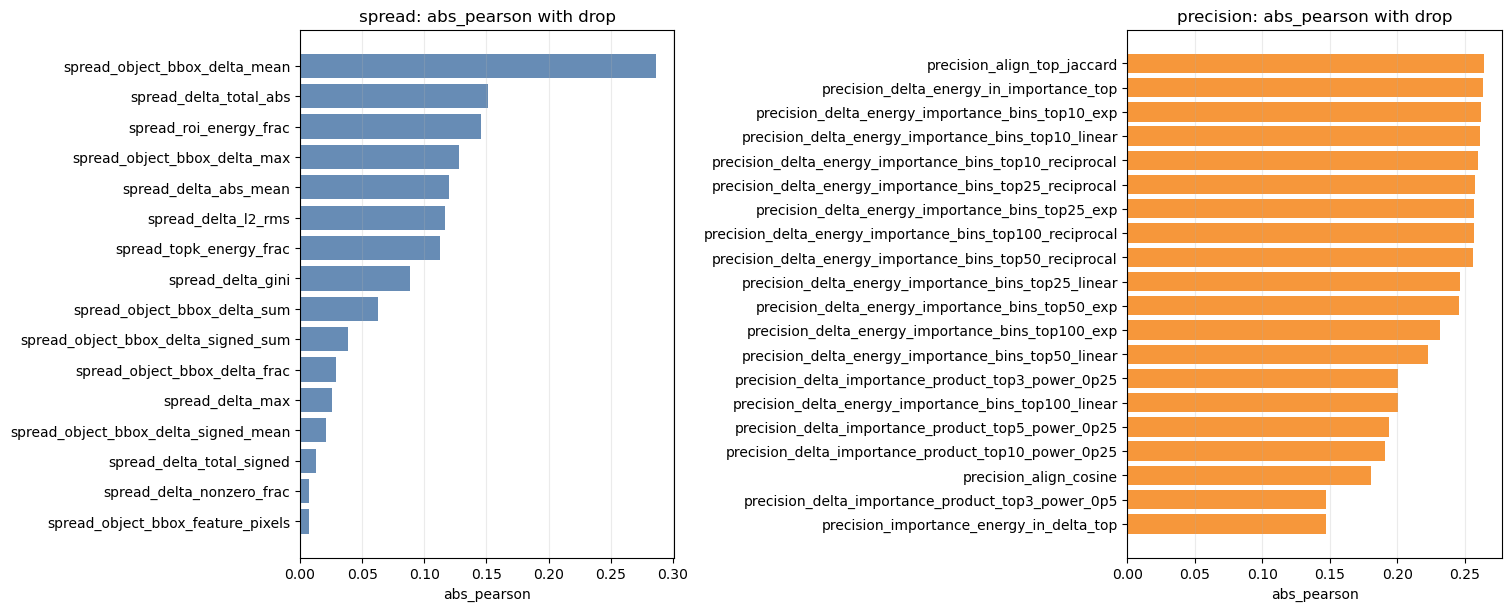

In [6]:
corr_summary = (
    regression_df.groupby("family")
    .agg(
        best_abs_spearman=("abs_spearman", "max"),
        best_abs_pearson=("abs_pearson", "max"),
        mean_top10_abs_spearman=("abs_spearman", lambda s: s.sort_values(ascending=False).head(10).mean()),
        mean_top10_abs_pearson=("abs_pearson", lambda s: s.sort_values(ascending=False).head(10).mean()),
    )
    .reset_index()
)
display(corr_summary)

fig = spread_precision.plot_family_correlation_bars(regression_df, corr_col="abs_spearman", top_n=20)
plt.show()

fig = spread_precision.plot_family_correlation_bars(regression_df, corr_col="abs_pearson", top_n=20)
plt.show()


## Top-10 самых уверенных success/fail: карты важности и дельт


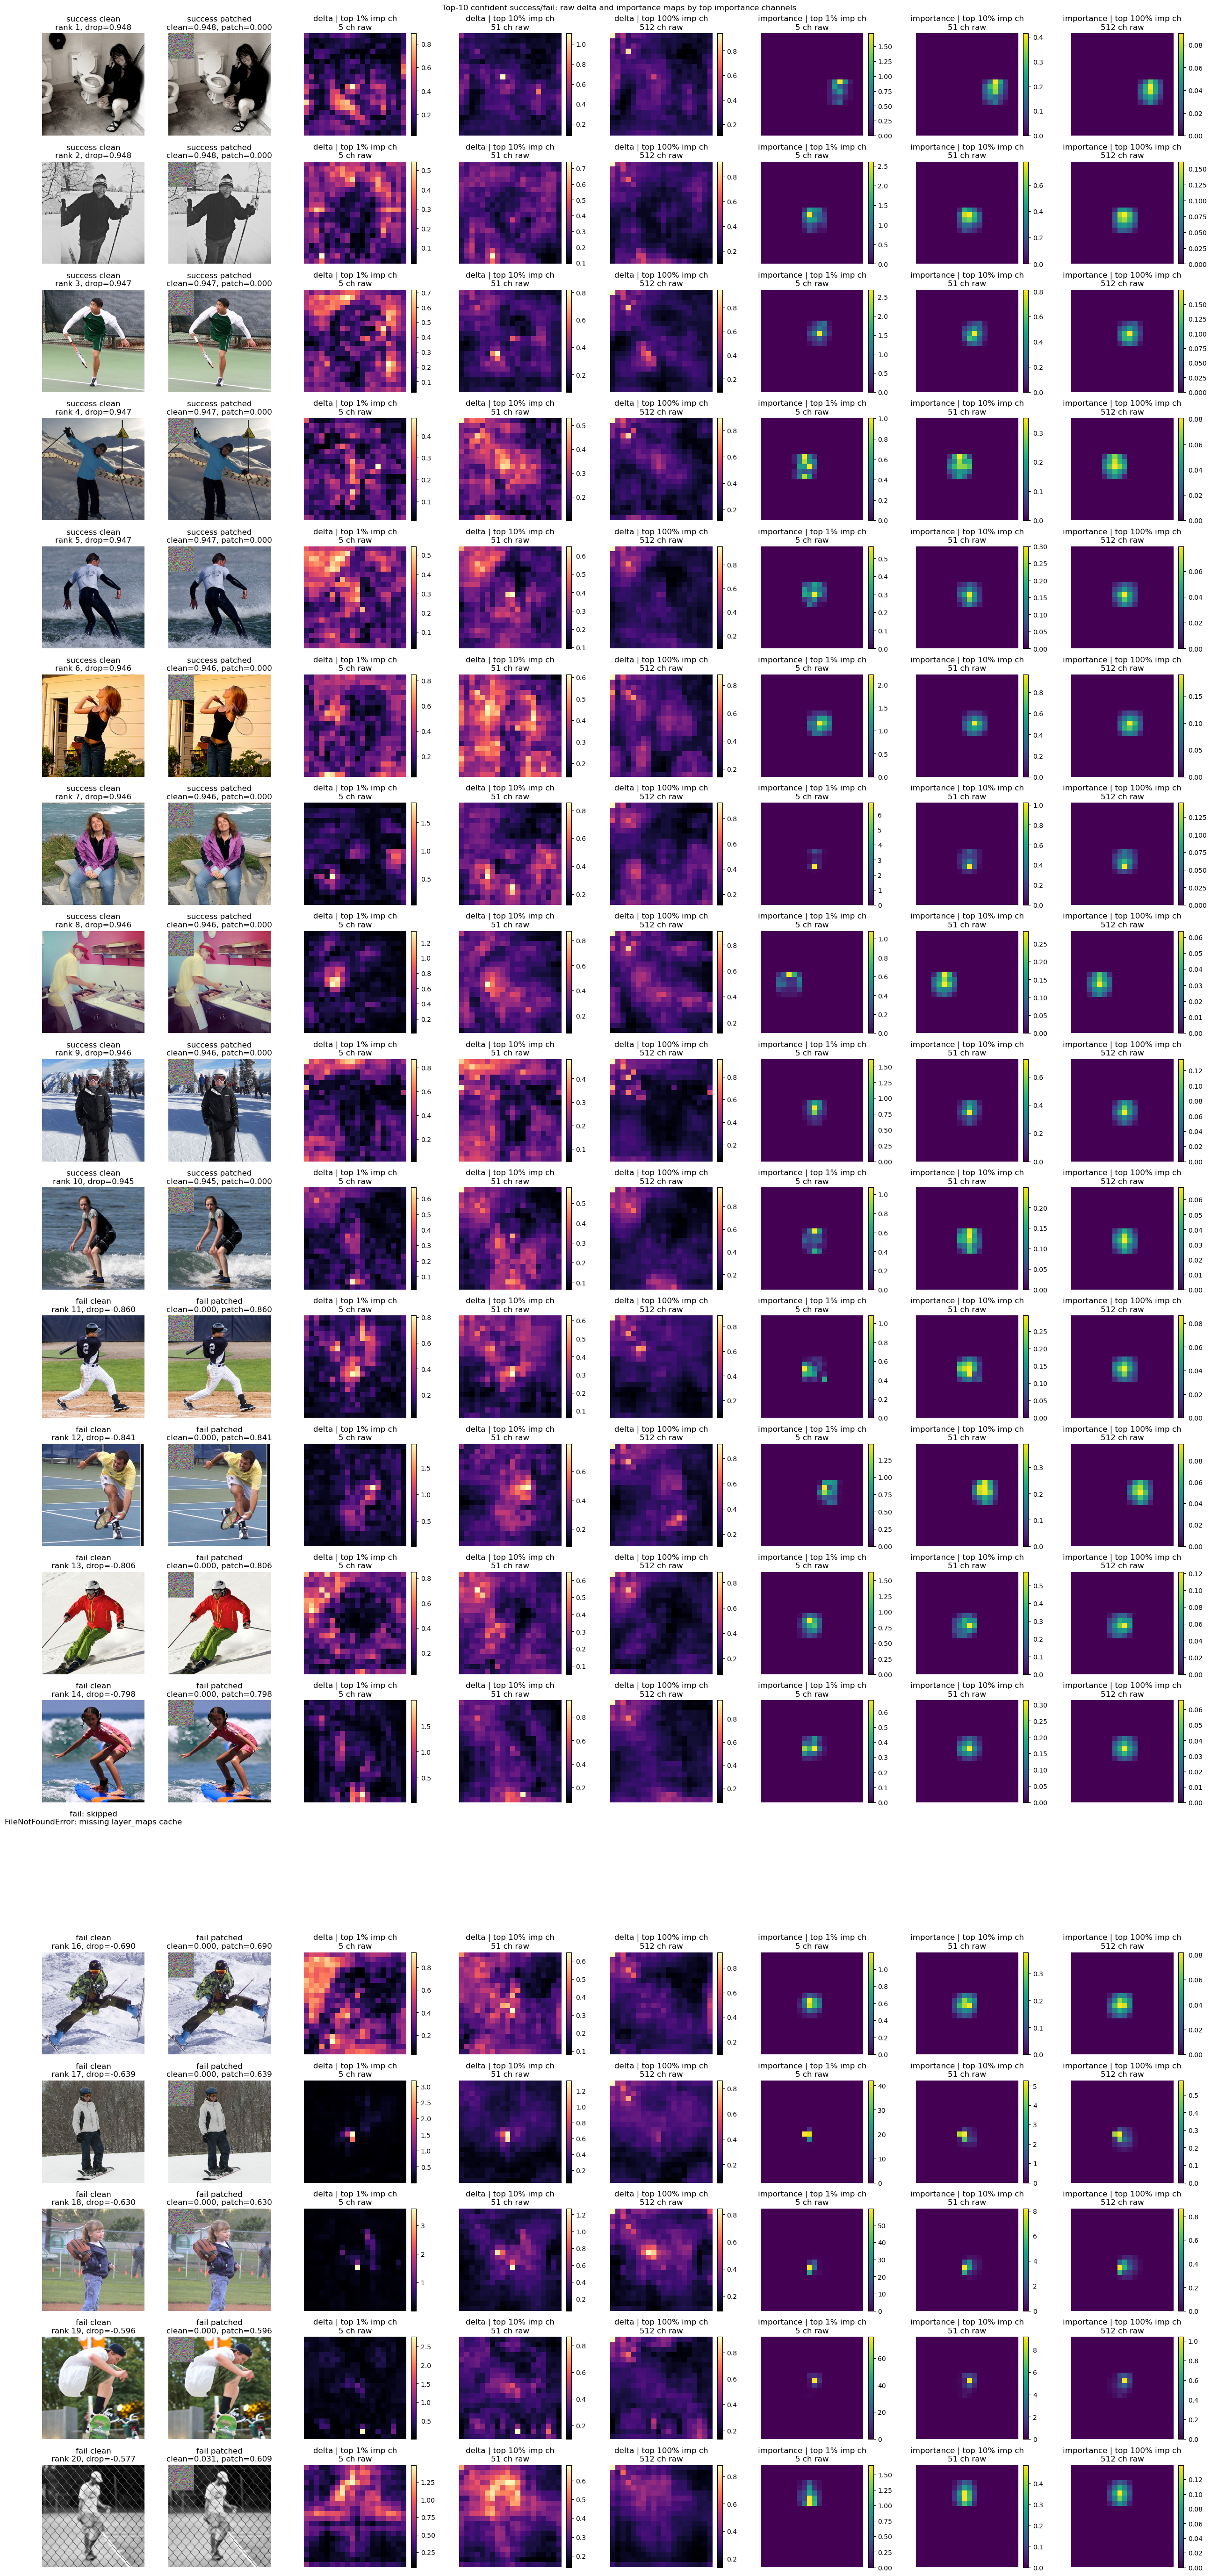

,path,group,reason
0,../datasets/COCO_people/03370_train2017_image5...,fail,FileNotFoundError: missing layer_maps cache


In [7]:
top_confident_n = 10
fig = spread_precision.plot_top_confident_channel_filtered_maps(
    exp,
    cache.examples,
    layer_name=layer_name,
    top_n_per_group=top_confident_n,
    fractions=(1, 10, 100),
)
plt.show()

skipped_maps = getattr(fig, "_spread_precision_skipped", [])
if skipped_maps:
    display(pd.DataFrame(skipped_maps))
